**DSML L 87 Neural network**

In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fashion_minst = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_minst.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print(train_images.shape)
print(train_labels.shape)

print(test_images.shape)
print(test_labels.shape)


(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


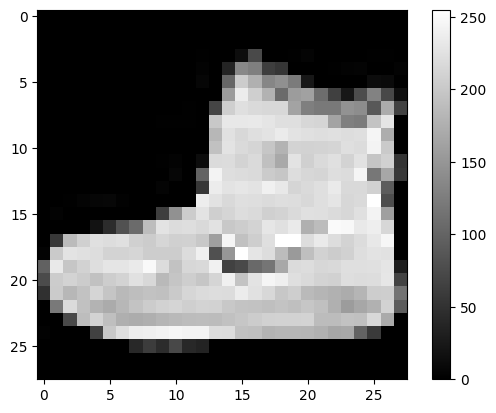

In [4]:
plt.figure()
plt.imshow(train_images[0], cmap='gray', vmin=0, vmax=255)
plt.colorbar()
plt.grid(False)


In [5]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [6]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt']

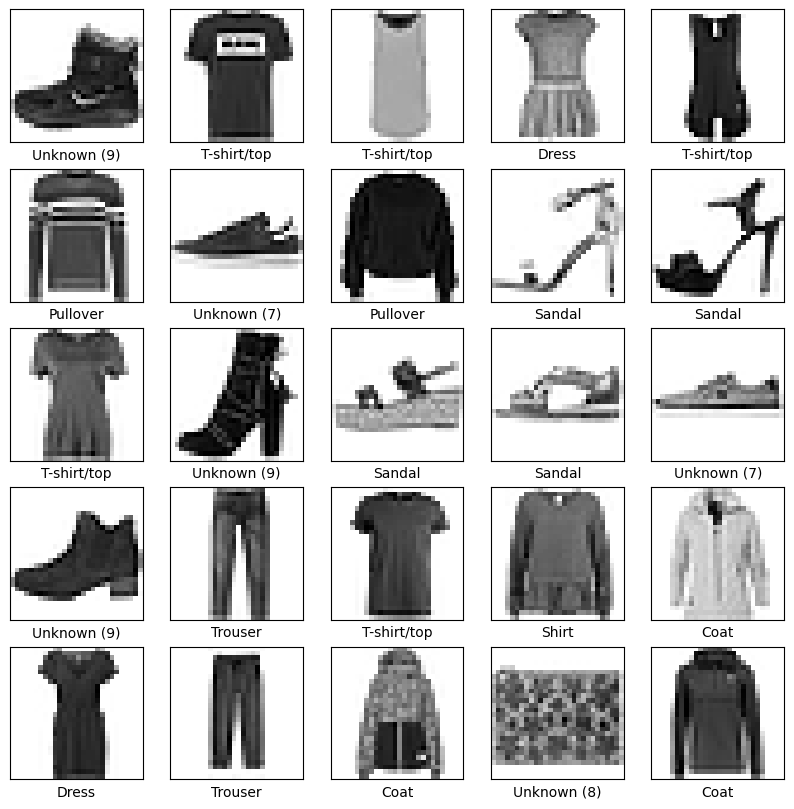

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
num_images = min(25, len(train_images))

for i in range(num_images):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)

    # FIX: Get the label value first
    label_idx = train_labels[i]

    # Check if the label index exists in class_names
    if label_idx < len(class_names):
        plt.xlabel(class_names[label_idx])
    else:
        plt.xlabel(f"Unknown ({label_idx})")

plt.show()



In [11]:
#simple 3 layer neural network

In [12]:
model_1= keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])
model_1.summary()

model_1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model_1.fit(train_images, train_labels, epochs=10,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8188 - loss: 0.5175 - val_accuracy: 0.8405 - val_loss: 0.4310
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8591 - loss: 0.3895 - val_accuracy: 0.8662 - val_loss: 0.3760
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8730 - loss: 0.3474 - val_accuracy: 0.8603 - val_loss: 0.3866
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8823 - loss: 0.3227 - val_accuracy: 0.8755 - val_loss: 0.3425
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8892 - loss: 0.3004 - val_accuracy: 0.8658 - val_loss: 0.3665
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8942 - loss: 0.2868 - val_accuracy: 0.8718 - val_loss: 0.3483
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8984 - loss: 0.2722 - val_accuracy: 0.8802 - val_loss: 0.3403
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9040 - loss: 0.2601 - 

In [14]:
test_loss, test_acc = model_1.evaluate(test_images, test_labels)
print('model -3 layers-test loss',test_loss * 100)
print('model -3 layers-test loss', test_acc *100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8733 - loss: 0.3568
model -3 layers-test loss 35.6753945350647
model -3 layers-test loss 87.33000159263611


In [15]:
#it has only 87% accuracy means it mistake a lot to overcome it we have to train by taking large layer means hyperparametertuning

6 layer model

In [16]:
model_2 = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation= tf.nn.relu),
    keras.layers.Dense(128, activation= tf.nn.relu),
    keras.layers.Dense(128, activation= tf.nn.relu),
    keras.layers.Dense(128, activation= tf.nn.relu),
    keras.layers.Dense(10, activation= tf.nn.softmax)
])

model_2.summary()

model_2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,306 (591.04 KB)

 Trainable params: 151,306 (591.04 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model_2.fit(train_images, train_labels, epochs=5, validation_split=0.2)

test_loss, test_acc = model_2.evaluate(test_images, test_labels)
print('model -6 layers-test loss',test_loss * 100)
print('model -6 layers-test loss', test_acc *100)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8094 - loss: 0.5241 - val_accuracy: 0.8447 - val_loss: 0.4182
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8588 - loss: 0.3847 - val_accuracy: 0.8482 - val_loss: 0.4073
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8749 - loss: 0.3429 - val_accuracy: 0.8708 - val_loss: 0.3559
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8803 - loss: 0.3223 - val_accuracy: 0.8721 - val_loss: 0.3474
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8872 - loss: 0.3055 - val_accuracy: 0.8749 - val_loss: 0.3403
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8701 - loss: 0.3645
model -6 layers-test loss 36.45225465297699
model -6 layers-test loss 87.01000213623047


**Quantization**

Quantization in deep learning is an optimization technique that reduces the precision of a model's numerical values (like weights and activations) to make the model smaller, faster, and more energy-efficient

Why use Quantization?
Reduced Model Size: Converting FP32 to INT8 can shrink a model's memory footprint by up to 4x.


Faster Inference: Integer operations are computationally "cheaper" and faster than floating-point math, especially on mobile CPUs and specialized AI accelerators.


Edge Deployment: It allows massive models (like LLMs) to run on resource-constrained devices like smartphones, IoT sensors, and microcontrollers.


Lower Power Consumption: Reduced data movement and simpler arithmetic save significant battery life and electricity

**tempreture softmax fn**

In deep learning—specifically for Large Language Models (LLMs)—Temperature (
) is a hyperparameter used to scale the logits (raw output scores) before they pass through the Softmax function.


It controls the randomness or "creativity" of the model's predictions by adjusting the probability distribution of the next token.

THIS IS IMPORTATNT LINK PLS READ IT

https://intellabs.github.io/distiller/knowledge_distillation.html